# 6. Quantitative structure models

From the points of one tree to a connected set of cylinders with volumes and
branch orders.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import qsm

tree = synthetic.tree(dbh=0.35, height=14.0, seed=4)
print(tree)

PointCloud(n=79,004, attrs=['classification'])


## Leaf / wood separation

`wood_points` combines local anisotropy with a topological cue: points that many
shortest paths from the base to the crown pass through are wood. The synthetic
tree knows which points are wood, so the filter can be checked.

28,264 wood points kept; 98.4% of them lie on true wood


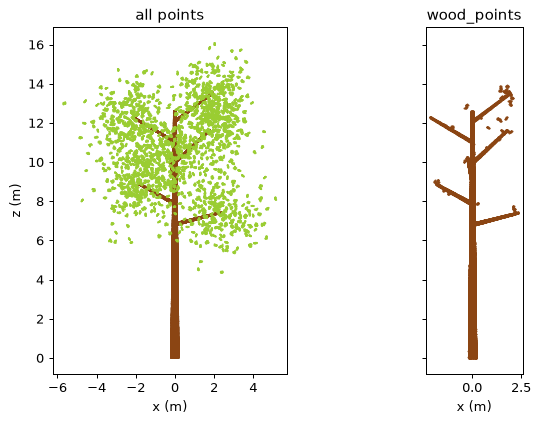

In [2]:
wood = qsm.wood_points(tree, voxel_size=0.02)
true_wood = tree[tree.attrs["classification"] == 5]
from sylva import filters
d, _ = filters.knn(true_wood.xyz, wood.xyz, 1)
print(f"{len(wood):,} wood points kept; {np.mean(d[:, 0] < 0.03):.1%} of them lie on true wood")

fig, ax = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
ax[0].scatter(tree.x, tree.z, s=0.3, c=np.where(tree.attrs["classification"] == 5, "saddlebrown", "yellowgreen"))
ax[0].set(title="all points", aspect="equal", xlabel="x (m)", ylabel="z (m)")
ax[1].scatter(wood.x, wood.z, s=0.3, c="saddlebrown")
ax[1].set(title="wood_points", aspect="equal", xlabel="x (m)");

## Cylinder model

In [3]:
model = qsm.build_qsm(wood, base_xy=(0.0, 0.0))
for k, v in model.summary().items():
    print(f"{k:18s} {v:.4f}" if isinstance(v, float) else f"{k:18s} {v}")

n_cylinders        342
total_volume_m3    0.6238
stem_volume_m3     0.5924
branch_volume_m3   0.0314
total_length_m     38.5652
max_branch_order   2
dbh_m              0.3403


The stem of the synthetic tree tapers from 1.05 to 0.25 times the breast-height radius over 90 % of the height, so its volume is known:

In [4]:
r0, r1, L = 0.35 / 2 * 1.05, 0.35 / 2 * 0.25, 14.0 * 0.9
true_stem = np.pi * L / 3 * (r0**2 + r0 * r1 + r1**2)
print(f"stem volume: model {model.stem_volume:.3f} m3, truth {true_stem:.3f} m3;  DBH: model {model.dbh:.3f} m, truth 0.35 m")

stem volume: model 0.592 m3, truth 0.577 m3;  DBH: model 0.340 m, truth 0.35 m


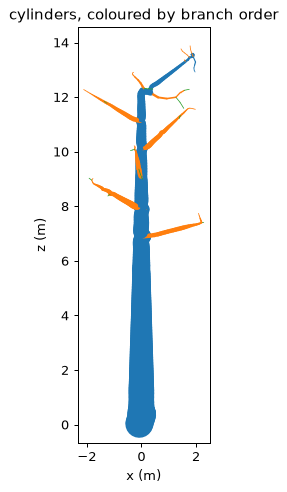

In [5]:
start, end = model.start, model.end
order = model.column("branch_order").astype(int)
fig, ax = plt.subplots(figsize=(5, 6))
for s, e, r, o in zip(start, end, model.column("radius"), order):
    ax.plot([s[0], e[0]], [s[2], e[2]], color=f"C{min(o, 9)}", lw=max(0.6, r * 120), solid_capstyle="round")
ax.set(aspect="equal", xlabel="x (m)", ylabel="z (m)", title="cylinders, coloured by branch order");

## Export

A cylinder table, a raycloudtools-style tree file, and meshes for Blender / CloudCompare.

In [6]:
model.to_csv("tree_qsm.csv")
model.to_ply("tree_qsm.ply")        # faces coloured by branch order
model.to_obj("tree_qsm.obj")
qsm.QSM.from_csv("tree_qsm.csv").summary()["n_cylinders"]

342